# Imports

In [ ]:
# Import necessary libraries
import csv
import random

import matplotlib.pyplot as plt
import numpy as np

# Import proto-language modules
from proto_language.language.core import (
    Sequence,
)
from proto_language.language.optimizer import (
    MCMCOptimizerConfig,
)

random.seed(42)
np.random.seed(42)

# Write Program

In [ ]:
mcmc_optimizer_config = MCMCOptimizerConfig(
    num_results=1,
    candidates_per_result=10,
    num_steps=N_STEPS,
    verbose=True,
)

# Run Program

In [27]:
program.run()
print(f"Generated {len(optimizer.history)} sequence snapshots during optimization")
# History is a list of dictionaries with keys: "time_step", "energy_scores", "constructs"
initial_construct = optimizer.history[0]["constructs"][0]
final_construct = program.constructs[0]


Energy Scoring: 0 filters, 5 scoring constraints
Formula: energy = Σ(weight_i x constraint_score_i)

Constraint 1: structure_plddt_constraint
  Candidate 0: 14.3533 = 0.7177 * 20
  Candidate 1: 14.3533 = 0.7177 * 20
  Candidate 2: 14.3533 = 0.7177 * 20
  Candidate 3: 14.3533 = 0.7177 * 20
  Candidate 4: 14.3533 = 0.7177 * 20
  Candidate 5: 14.3533 = 0.7177 * 20
  Candidate 6: 14.3533 = 0.7177 * 20
  Candidate 7: 14.3533 = 0.7177 * 20
  Candidate 8: 14.3533 = 0.7177 * 20
  Candidate 9: 14.3533 = 0.7177 * 20
Constraint 2: structure_ptm_constraint
  Candidate 0: 16.9341 = 0.8467 * 20
  Candidate 1: 16.9341 = 0.8467 * 20
  Candidate 2: 16.9341 = 0.8467 * 20
  Candidate 3: 16.9341 = 0.8467 * 20
  Candidate 4: 16.9341 = 0.8467 * 20
  Candidate 5: 16.9341 = 0.8467 * 20
  Candidate 6: 16.9341 = 0.8467 * 20
  Candidate 7: 16.9341 = 0.8467 * 20
  Candidate 8: 16.9341 = 0.8467 * 20
  Candidate 9: 16.9341 = 0.8467 * 20
Constraint 3: protein_symmetry_ring_constraint
  Candidate 0: 0.2967
  Candida

# Save Metadata

In [28]:
metadata = final_construct.joined_sequences[0]._metadata
print(metadata)

# Save metadata to CSV (create directory if needed)
import os

os.makedirs('metadata_examples', exist_ok=True)
with open('metadata_examples/esm2_example_metadata.csv', 'w') as f:
    writer = csv.DictWriter(f, fieldnames=metadata.keys())
    writer.writeheader()
    writer.writerow(metadata)

{'segment_0.structure_plddt_constraint.avg_plddt': 0.7063590884208679, 'segment_0.structure_plddt_constraint.pdb_output': 'ATOM      1  N   THR A   1      12.248  13.460  22.456  1.00  0.41          N  \nATOM      2  CA  THR A   1      11.923  12.936  21.134  1.00  0.42          C  \nATOM      3  C   THR A   1      11.810  11.415  21.167  1.00  0.42          C  \nATOM      4  CB  THR A   1      12.979  13.352  20.093  1.00  0.38          C  \nATOM      5  O   THR A   1      12.712  10.731  21.654  1.00  0.41          O  \nATOM      6  CG2 THR A   1      12.436  14.429  19.159  1.00  0.36          C  \nATOM      7  OG1 THR A   1      14.135  13.860  20.770  1.00  0.36          O  \nATOM      8  N   VAL A   2      10.623  10.788  21.240  1.00  0.49          N  \nATOM      9  CA  VAL A   2      10.589   9.335  21.377  1.00  0.50          C  \nATOM     10  C   VAL A   2      11.019   8.682  20.066  1.00  0.50          C  \nATOM     11  CB  VAL A   2       9.184   8.837  21.785  1.00  0.47 

# Visualize Results

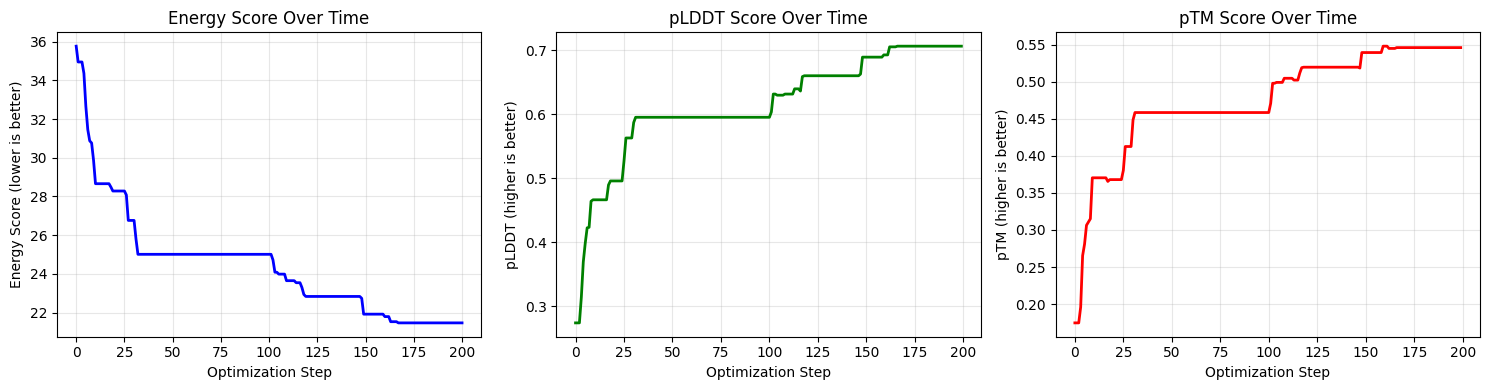


Optimization Summary:
Initial sequence: VDMGGAVTHYEQDHFGSCDTFTEGRYMDIE
Final sequence:   TVEGAAITSYHRDHLGSVRAITEGRTADNV
Energy improvement: 35.762 → 21.473
pLDDT improvement:  0.274 → 0.706
pTM improvement:    0.175 → 0.546

Final protein will form a 3-fold symmetric ring structure


In [29]:
# Extract metrics from history - handle different metadata key formats
def get_metric(metadata, metric_name):
    """Get metric from metadata, handling suffixed keys."""
    if metric_name in metadata:
        return metadata[metric_name]
    for key in metadata.keys():
        if key.endswith(metric_name):
            return metadata[key]
    return None

# History is a list of dictionaries with keys: "time_step", "energy_scores", "constructs"
energy_scores = [c["energy_scores"][0] for c in optimizer.history]
plddt_scores = [get_metric(c["constructs"][0].joined_sequences[0]._metadata, 'avg_plddt') for c in optimizer.history]
ptm_scores = [get_metric(c["constructs"][0].joined_sequences[0]._metadata, 'ptm') for c in optimizer.history]

# Filter out None values for plotting
energy_scores = [e for e in energy_scores if e is not None]
plddt_scores = [p for p in plddt_scores if p is not None]
ptm_scores = [p for p in ptm_scores if p is not None]

# Plot optimization progress
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Energy score plot
if energy_scores:
    axes[0].plot(energy_scores, 'b-', linewidth=2)
    axes[0].set_title('Energy Score Over Time')
    axes[0].set_xlabel('Optimization Stage')
    axes[0].set_ylabel('Energy Score (lower is better)')
    axes[0].grid(True, alpha=0.3)

# pLDDT score plot
if plddt_scores:
    axes[1].plot(plddt_scores, 'g-', linewidth=2)
    axes[1].set_title('pLDDT Score Over Time')
    axes[1].set_xlabel('Optimization Stage')
    axes[1].set_ylabel('pLDDT (higher is better)')
    axes[1].grid(True, alpha=0.3)

# pTM score plot
if ptm_scores:
    axes[2].plot(ptm_scores, 'r-', linewidth=2)
    axes[2].set_title('pTM Score Over Time')
    axes[2].set_xlabel('Optimization Stage')
    axes[2].set_ylabel('pTM (higher is better)')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nOptimization Summary:")
print(f"Initial sequence: {initial_construct.joined_sequences[0]._sequence}")
print(f"Final sequence:   {final_construct.joined_sequences[0]._sequence}")

if energy_scores:
    print(f"Energy improvement: {energy_scores[0]:.3f} → {energy_scores[-1]:.3f}")
if plddt_scores:
    print(f"pLDDT improvement:  {plddt_scores[0]:.3f} → {plddt_scores[-1]:.3f}")
if ptm_scores:
    print(f"pTM improvement:    {ptm_scores[0]:.3f} → {ptm_scores[-1]:.3f}")

print(f"\nFinal protein will form a {N_SYMMETRIC_UNITS}-fold symmetric ring structure")


In [ ]:
import py3Dmol


def visualize_structure_in_notebook(sequence: Sequence):
    """
    Visualize protein structure directly in Jupyter notebook using py3Dmol.
    This works without requiring PyMOL installation.
    """
    pdb_content = get_metric(sequence._metadata, 'pdb_output')
    if pdb_content is None:
        print("No PDB structure available in metadata")
        return None

    # Create 3D viewer
    viewer = py3Dmol.view(width=800, height=600)

    # Add the structure
    viewer.addModel(pdb_content, 'pdb')

    # Style the structure
    viewer.setStyle({'cartoon': {'color': 'spectrum'}})

    # If it's a multimer, color chains differently
    chains = set()
    for line in pdb_content.split('\n'):
        if line.startswith('ATOM'):
            chain = line[21]
            chains.add(chain)

    if len(chains) > 1:
        colors = ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'cyan', 'magenta']
        for i, chain in enumerate(sorted(chains)):
            color = colors[i % len(colors)]
            viewer.setStyle({'chain': chain}, {'cartoon': {'color': color}})

    # Center and zoom
    viewer.zoomTo()

    plddt = get_metric(sequence._metadata, 'avg_plddt')
    ptm = get_metric(sequence._metadata, 'ptm')
    print(f"pLDDT: {plddt:.3f}" if plddt else "pLDDT: N/A")
    print(f"pTM: {ptm:.3f}" if ptm else "pTM: N/A")
    print(f"Sequence: {sequence.sequence}")
    return viewer


print("Initial Structure")
# Note: For initial construct, metadata is in candidate_sequences (not result_sequences)
# because the snapshot was taken before the first MH acceptance step copied candidates to result_sequences
initial_viewer = visualize_structure_in_notebook(initial_construct.segments[0].candidate_sequences[0])
if initial_viewer:
    initial_viewer.show()

print("\nFinal Structure")
final_viewer = visualize_structure_in_notebook(final_construct.joined_sequences[0])
if final_viewer:
    final_viewer.show()